In [1]:
from specify_cells import *

numprocs=1


In [2]:
stim_dt = 0.025
dt = 0.025
equilibrate = 250.  # time to steady-state
duration = equilibrate + 100.
ISI = 20.
stochastic = True

In [3]:
exc_syn_types = ['AMPA_KIN', 'NMDA_KIN5']
inh_syn_types = ['GABA_A_KIN']

local_random = random.Random()

In [4]:
cell = Passive_Soma(mech_filename='20241127_single_compartment_biophysics.yaml')

In [5]:
syn = cell.insert_synapse(exc_syn_types, stochastic=stochastic)

In [6]:
if stochastic:
    rand_seq = syn.randObj.seq()

In [7]:
cell.init_synaptic_mechanisms()

In [8]:
sim = QuickSim(duration, cvode=False, dt=dt)

In [9]:
sim.append_rec(cell, cell.tree.root, description='soma')

In [10]:
stim_train = np.arange(equilibrate, duration, ISI)
syn.source.play(h.Vector(stim_train))

1.0

In [11]:
sim.run()

Simulation runtime:  0.026640892028808594  sec


/Users/aaronmil/src/CA1Sim/specify_cells.py:2109: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


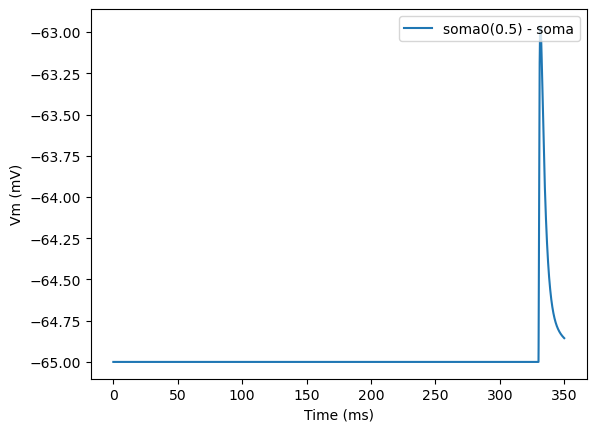

In [12]:
sim.plot()